In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Load cleaned data
df = pd.read_csv('../data/cardio_cleaned.csv')

# Load model and scaler
model = joblib.load('../backend/models/xgb_model.pkl')
scaler = joblib.load('../backend/models/scaler.pkl')

with open('../backend/models/feature_names.json') as f:
    feature_names = json.load(f)

print("Everything loaded!")
print("Dataset shape:", df.shape)

Everything loaded!
Dataset shape: (68517, 12)


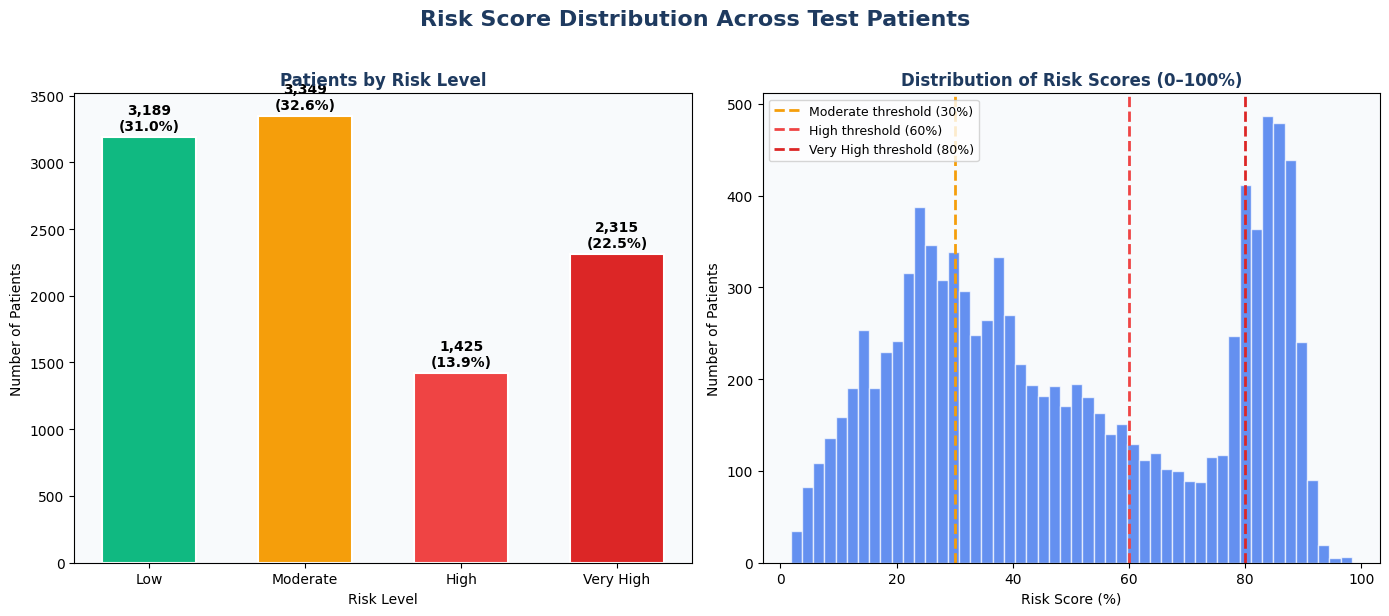

Saved: risk_score_distribution.png


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recreate feature engineering
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['chol_glucose_risk'] = df['cholesterol'] + df['gluc']
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,100], labels=[0,1,2,3]).astype(int)
df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)

X = df[feature_names]
y = df['cardio']

# Split and scale
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s  = scaler2.transform(X_test)

# Get risk scores for all test patients
probabilities = model.predict_proba(X_test_s)[:, 1]
risk_scores = probabilities * 100

# Assign risk levels
def get_level(p):
    if p < 30: return 'Low'
    elif p < 60: return 'Moderate'
    elif p < 80: return 'High'
    else: return 'Very High'

levels = [get_level(s) for s in risk_scores]
level_counts = pd.Series(levels).value_counts()
level_order = ['Low', 'Moderate', 'High', 'Very High']
colors = ['#10B981', '#F59E0B', '#EF4444', '#DC2626']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Risk Score Distribution Across Test Patients', 
             fontsize=16, fontweight='bold', color='#1E3A5F', y=1.02)

# Left — Bar chart of risk levels
counts = [level_counts.get(l, 0) for l in level_order]
bars = ax1.bar(level_order, counts, color=colors, 
               edgecolor='white', linewidth=1.5, width=0.6)
ax1.set_title('Patients by Risk Level', fontweight='bold', color='#1E3A5F')
ax1.set_xlabel('Risk Level')
ax1.set_ylabel('Number of Patients')
ax1.set_facecolor('#F8FAFC')
for bar, count in zip(bars, counts):
    pct = count / len(risk_scores) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Right — Histogram of raw scores
ax2.hist(risk_scores, bins=50, color='#2563EB', alpha=0.7, edgecolor='white')
ax2.axvline(x=30, color='#F59E0B', linestyle='--', linewidth=2, label='Moderate threshold (30%)')
ax2.axvline(x=60, color='#EF4444', linestyle='--', linewidth=2, label='High threshold (60%)')
ax2.axvline(x=80, color='#DC2626', linestyle='--', linewidth=2, label='Very High threshold (80%)')
ax2.set_title('Distribution of Risk Scores (0–100%)', fontweight='bold', color='#1E3A5F')
ax2.set_xlabel('Risk Score (%)')
ax2.set_ylabel('Number of Patients')
ax2.set_facecolor('#F8FAFC')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_score_distribution.png")

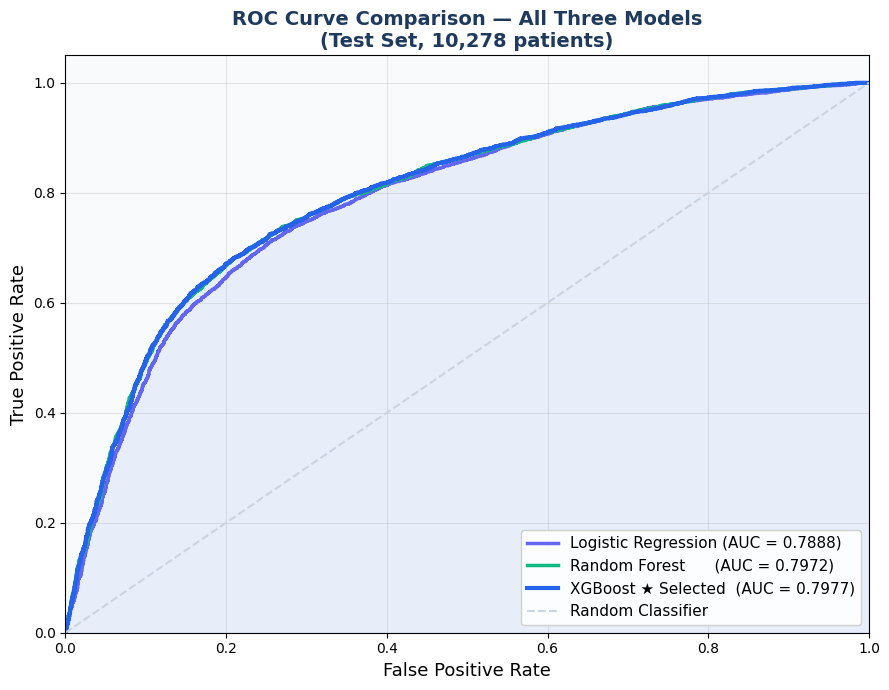

Saved: roc_curve_comparison.png


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Retrain all 3 models quickly for ROC curves
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

lr.fit(X_train_s, y_train)
rf.fit(X_train_s, y_train)

# Get probabilities
lr_proba  = lr.predict_proba(X_test_s)[:, 1]
rf_proba  = rf.predict_proba(X_test_s)[:, 1]
xgb_proba = model.predict_proba(X_test_s)[:, 1]

# Compute ROC curves
lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_proba)
rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

lr_auc  = auc(lr_fpr, lr_tpr)
rf_auc  = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(lr_fpr,  lr_tpr,  color='#6366F1', lw=2.5,
        label=f'Logistic Regression (AUC = {lr_auc:.4f})')
ax.plot(rf_fpr,  rf_tpr,  color='#10B981', lw=2.5,
        label=f'Random Forest      (AUC = {rf_auc:.4f})')
ax.plot(xgb_fpr, xgb_tpr, color='#2563EB', lw=3,
        label=f'XGBoost ★ Selected  (AUC = {xgb_auc:.4f})')
ax.plot([0,1], [0,1], color='#CBD5E1', linestyle='--', lw=1.5, label='Random Classifier')

ax.fill_between(xgb_fpr, xgb_tpr, alpha=0.08, color='#2563EB')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison — All Three Models\n(Test Set, 10,278 patients)',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_facecolor('#F8FAFC')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve_comparison.png")

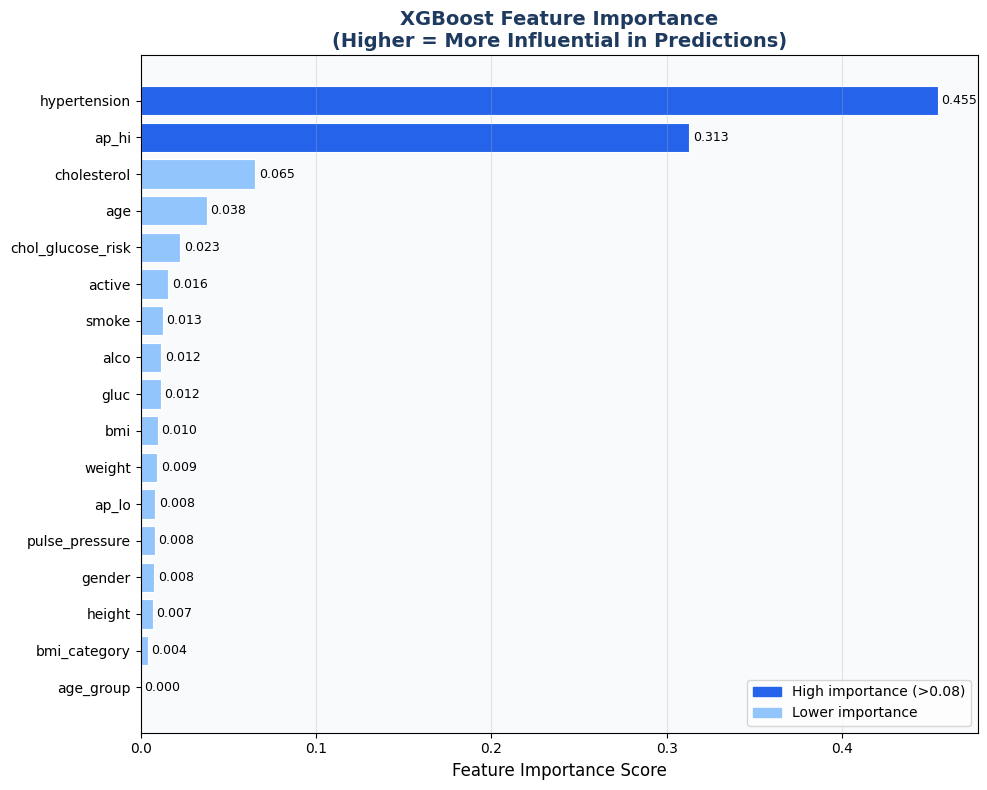

Saved: feature_importance_xgboost.png


In [4]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors_imp = ['#2563EB' if imp > 0.08 else '#93C5FD' 
              for imp in feat_imp['Importance']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=colors_imp, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('XGBoost Feature Importance\n(Higher = More Influential in Predictions)',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.set_facecolor('#F8FAFC')

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

high_patch = mpatches.Patch(color='#2563EB', label='High importance (>0.08)')
low_patch  = mpatches.Patch(color='#93C5FD', label='Lower importance')
ax.legend(handles=[high_patch, low_patch], fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/feature_importance_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_xgboost.png")

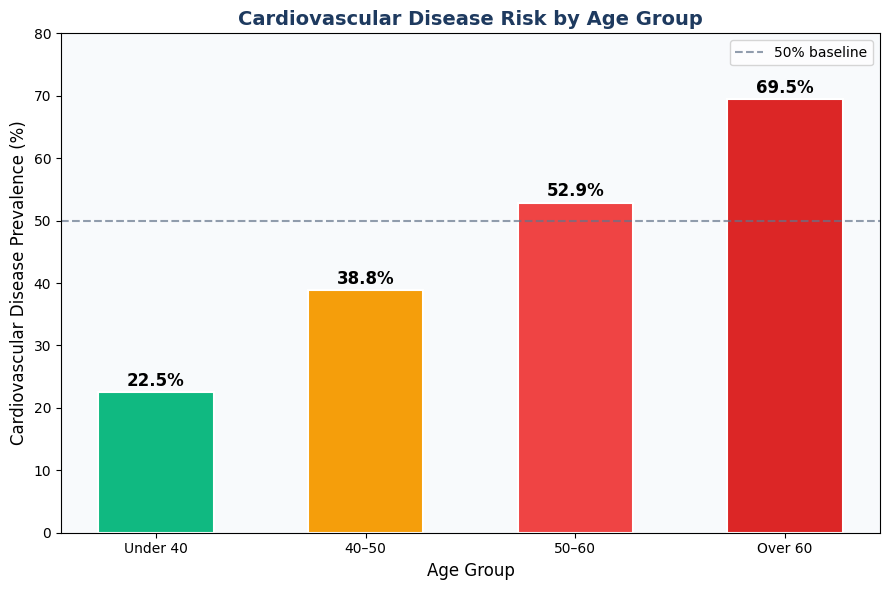

Saved: risk_by_age_group.png


In [5]:
age_bins   = [0, 40, 50, 60, 100]
age_labels = ['Under 40', '40–50', '50–60', 'Over 60']
df['age_group_label'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

age_risk = df.groupby('age_group_label', observed=True)['cardio'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#10B981', '#F59E0B', '#EF4444', '#DC2626']
bars = ax.bar(age_risk.index, age_risk.values,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)

ax.axhline(y=50, color='#64748B', linestyle='--', 
           linewidth=1.5, alpha=0.7, label='50% baseline')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Cardiovascular Disease Prevalence (%)', fontsize=12)
ax.set_title('Cardiovascular Disease Risk by Age Group',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.set_ylim(0, 80)
ax.set_facecolor('#F8FAFC')
ax.legend(fontsize=10)

for bar, val in zip(bars, age_risk.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/risk_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_by_age_group.png")

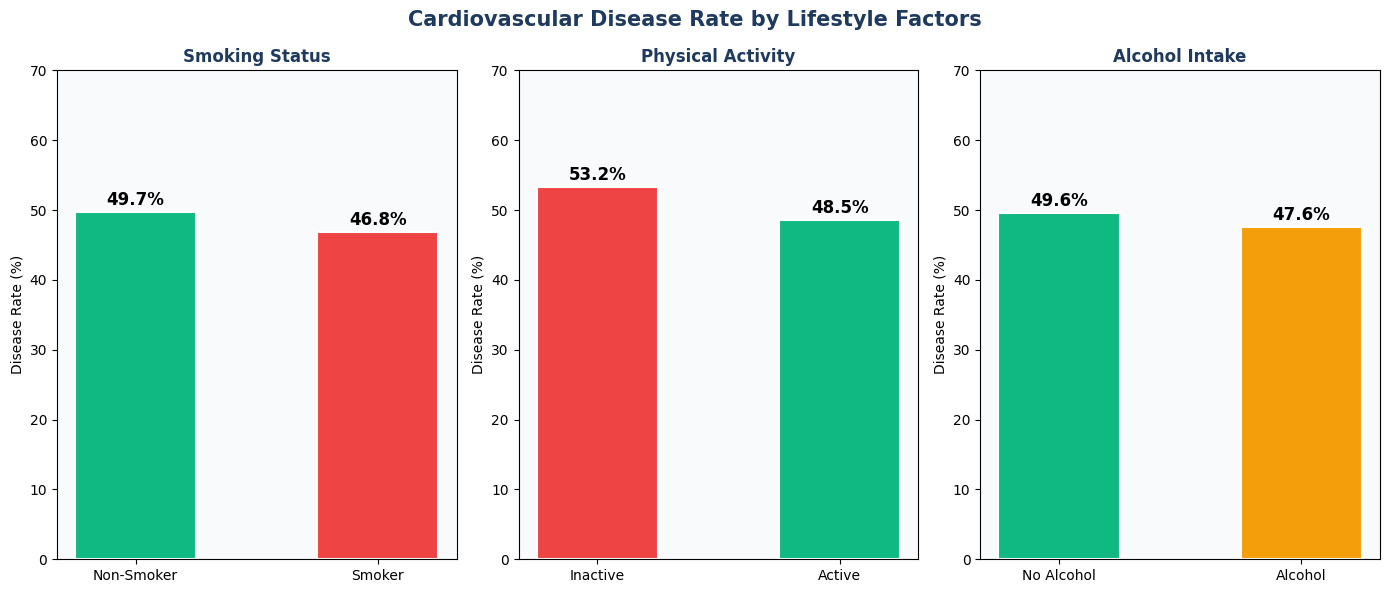

Saved: risk_by_lifestyle.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Cardiovascular Disease Rate by Lifestyle Factors',
             fontsize=15, fontweight='bold', color='#1E3A5F')

lifestyle = [
    ('smoke',  ['Non-Smoker', 'Smoker'],   ['#10B981', '#EF4444'], 'Smoking Status'),
    ('active', ['Inactive',   'Active'],   ['#EF4444', '#10B981'], 'Physical Activity'),
    ('alco',   ['No Alcohol', 'Alcohol'],  ['#10B981', '#F59E0B'], 'Alcohol Intake'),
]

for ax, (col, labels, colors, title) in zip(axes, lifestyle):
    rates = df.groupby(col)['cardio'].mean() * 100
    bars = ax.bar(labels, rates.values, color=colors,
                  edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(title, fontweight='bold', color='#1E3A5F', fontsize=12)
    ax.set_ylabel('Disease Rate (%)', fontsize=10)
    ax.set_ylim(0, 70)
    ax.set_facecolor('#F8FAFC')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.1f}%', ha='center',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/risk_by_lifestyle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_by_lifestyle.png")

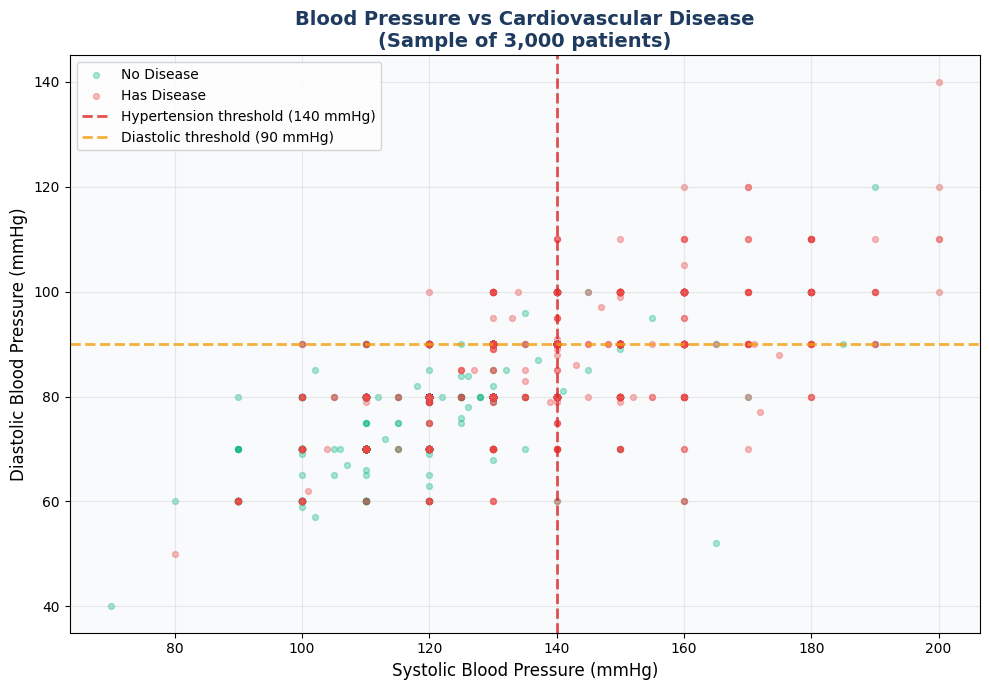

Saved: bp_vs_disease.png


In [7]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))

no_disease = sample[sample['cardio'] == 0]
disease    = sample[sample['cardio'] == 1]

ax.scatter(no_disease['ap_hi'], no_disease['ap_lo'],
           alpha=0.35, color='#10B981', s=18, label='No Disease')
ax.scatter(disease['ap_hi'], disease['ap_lo'],
           alpha=0.35, color='#EF4444', s=18, label='Has Disease')

ax.axvline(x=140, color='#DC2626', linestyle='--',
           linewidth=2, alpha=0.8, label='Hypertension threshold (140 mmHg)')
ax.axhline(y=90,  color='#F59E0B', linestyle='--',
           linewidth=2, alpha=0.8, label='Diastolic threshold (90 mmHg)')

ax.set_xlabel('Systolic Blood Pressure (mmHg)', fontsize=12)
ax.set_ylabel('Diastolic Blood Pressure (mmHg)', fontsize=12)
ax.set_title('Blood Pressure vs Cardiovascular Disease\n(Sample of 3,000 patients)',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.legend(fontsize=10, loc='upper left')
ax.set_facecolor('#F8FAFC')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('../data/bp_vs_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bp_vs_disease.png")